# GIBridge Stage 2 -- Training (consumes `GIBridge_Stage2_DataPrep_v3` output)

**Two-notebook workflow, matching your established pattern:**
1. `GIBridge_Stage2_DataPrep_v3.ipynb` (your existing `gi-stage-2` notebook, gene-selection
   pointer updated to Stage 1 v3) -- raw CCLE/GDSC2 -> scaled parquets + splits + Morgan FPs.
   Run that first, upload its `/kaggle/working/` output as a Kaggle dataset.
2. **This notebook** -- loads that dataset directly (`DATA_BASE`), no raw CCLE/GDSC2 code
   here at all, same as your `gi-stage-22.ipynb` loading pattern.

```
mRNA/CNV/Mut/Meth (pre-scaled) --> FROZEN Stage 1 v3 encoders --> 128-d patient embedding
SMILES-derived Morgan FP (pre-computed) --> Linear->64->GELU->32-d drug embedding (trainable)
prediction = drug_bias[drug_id] + residual_MLP( concat(patient_emb, drug_emb) )   [160->64->GELU->Dropout->1]
```

No lineage term, no backbone unfreezing (both dropped per your own ablation evidence).
Loss: Huber. Metrics: PCC / SCC / RMSE / R\u00b2 only, on whichever split(s) are enabled below.

**`CONFIG['run_warm']` / `CONFIG['run_cellcold']`** -- toggle either off to skip loading,
training, baselines, and figures for that split.

**Update these two paths for your environment:**
- `DATA_BASE` -- the Kaggle dataset built from `GIBridge_Stage2_DataPrep_v3.ipynb`'s output
- `CKPT_PATH` -- your Stage 1 v3 checkpoint (`gibridge_best.pt`)

All figures: truncated-viridis palette, 300 DPI PNG + PDF.
**Not verified in this environment this round, per your instruction.**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import copy, time, json, random, warnings, gc
warnings.filterwarnings('ignore')

# -- figure style: identical convention to Stage 1 and OncoBridge Stage 2 -----
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 10
mpl.rcParams['xtick.labelsize'] = 9
mpl.rcParams['ytick.labelsize'] = 9
mpl.rcParams['legend.fontsize'] = 9
mpl.rcParams['figure.dpi'] = 130
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.axis'] = 'y'
mpl.rcParams['grid.alpha'] = 0.30
mpl.rcParams['axes.axisbelow'] = True

VIRIDIS = plt.get_cmap('viridis')

def viridis_colors(n, low=0.15, high=0.95):
    if n == 1:
        return [VIRIDIS(high)]
    return [VIRIDIS(low + (high - low) * i / (n - 1)) for i in range(n)]

BASELINE_GREY = '#888888'
SINGLE_COL, DOUBLE_COL = (3.5, 3.0), (7.0, 3.4)

def section(title):
    print('\n' + '=' * 70)
    print(f'  {title}')
    print('=' * 70)

def save_fig(fig, name, out_dir):
    fig.savefig(f'{out_dir}{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(f'{out_dir}{name}.pdf', bbox_inches='tight')

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

# =============================================================================
#  TOGGLE -- change and re-run for whichever split(s) you want this run
# =============================================================================
RUN_WARM = True
RUN_COLD = True
assert RUN_WARM or RUN_COLD, 'enable at least one of RUN_WARM / RUN_COLD'

DATA_BASE = '/kaggle/input/datasets/proutkarshtiwari/gastric-stage2-data'   # UPDATE -- GIBridge_Stage2_DataPrep_v3 output
CKPT_PATH = '/kaggle/input/datasets/proutkarshtiwari/gi-outputeee-stage-1/gibridge_best.pt'  # UPDATE

PATH_MRNA = f'{DATA_BASE}/ccle_mrna_gi_scaled.parquet'
PATH_CNV  = f'{DATA_BASE}/ccle_cnv_gi_scaled.parquet'
PATH_MUT  = f'{DATA_BASE}/ccle_mut_gi_scaled.parquet'
PATH_METH = f'{DATA_BASE}/ccle_meth_gi_scaled.parquet'

SPLIT_PATHS = {
    'warm':      {'train': f'{DATA_BASE}/split_gi_warm_tr.parquet',
                  'val':   f'{DATA_BASE}/split_gi_warm_vl.parquet',
                  'test':  f'{DATA_BASE}/split_gi_warm_te.parquet'},
    'cell_cold': {'train': f'{DATA_BASE}/split_gi_cc_tr.parquet',
                  'val':   f'{DATA_BASE}/split_gi_cc_vl.parquet',
                  'test':  f'{DATA_BASE}/split_gi_cc_te.parquet'},
}

CONFIG = dict(
    embed_dim  = 32,     # must match Stage 1 v3
    hidden_dim = 64,     # must match Stage 1 v3
    dropout    = 0.30,
    drug_embed_dim = 32,

    main_epochs   = 150,
    main_patience = 20,
    batch_size    = 32,
    lr            = 3e-4,
    weight_decay  = 1e-4,
    clip_grad     = 1.0,
    huber_beta    = 1.0,
    seeds         = [42, 7, 123],
    seed          = 42,

    OUT_DIR = '/kaggle/working/',
)

set_seed(CONFIG['seed'])
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
print(f'Device: {DEVICE}')
print(f'RUN_WARM={RUN_WARM}  RUN_COLD={RUN_COLD}')

  GPU: Tesla T4
Device: cuda:0
RUN_WARM=True  RUN_COLD=True


In [2]:
section('Load processed data & splits')

t0 = time.time()
mrna_df = pd.read_parquet(PATH_MRNA)
cnv_df  = pd.read_parquet(PATH_CNV)
mut_df  = pd.read_parquet(PATH_MUT)
meth_df = pd.read_parquet(PATH_METH)
print(f'Loaded omics in {time.time()-t0:.1f}s')
print(f'mRNA {mrna_df.shape} | CNV {cnv_df.shape} | Mut {mut_df.shape} | Meth {meth_df.shape}')

gene_counts = {'mrna': mrna_df.shape[1], 'cnv': cnv_df.shape[1], 'mut': mut_df.shape[1], 'meth': meth_df.shape[1]}
print(f'Gene counts (should match Stage 1 v3 exactly): {gene_counts}')

with open(f'{DATA_BASE}/gi_drug2idx.json') as f:
    drug_to_idx = json.load(f)
DRUG_NAMES = pd.read_csv(f'{DATA_BASE}/gi_valid_drug_names.csv', header=None)[0].tolist()
num_drugs = len(DRUG_NAMES)
print(f'GI drugs: {num_drugs}')

morgan_fp_matrix = np.load(f'{DATA_BASE}/gi_drug_morgan_fps.npy').astype(np.float32)
with open(f'{DATA_BASE}/gi_drug_morgan_fp_order.json') as f:
    morgan_fp_order = json.load(f)
drug_to_morgan_idx = {d: i for i, d in enumerate(morgan_fp_order)}
print(f'Morgan FP matrix: {morgan_fp_matrix.shape}')

all_cell_lines = sorted(mrna_df.index.tolist())
cl_to_idx = {cl: i for i, cl in enumerate(all_cell_lines)}

mrna_arr = mrna_df.loc[all_cell_lines].values.astype(np.float32)
cnv_arr  = cnv_df.loc[all_cell_lines].values.astype(np.float32)
mut_arr  = mut_df.loc[all_cell_lines].values.astype(np.float32)
meth_arr = meth_df.loc[all_cell_lines].values.astype(np.float32)
del mrna_df, cnv_df, mut_df, meth_df
gc.collect()

def load_and_map_split(path):
    df = pd.read_parquet(path)
    df['cl_idx']   = df['ModelID'].map(cl_to_idx)
    df['drug_idx'] = df['DRUG_NAME'].map(drug_to_idx)
    before = len(df)
    df = df.dropna(subset=['cl_idx', 'drug_idx'])
    if len(df) < before:
        print(f'    [warn] {before - len(df)} rows dropped (unmatched cell line/drug) in {path.split("/")[-1]}')
    df['cl_idx']   = df['cl_idx'].astype(int)
    df['drug_idx'] = df['drug_idx'].astype(int)
    return df

warm_train = warm_val = warm_test = None
cc_train = cc_val = cc_test = None

if RUN_WARM:
    print('\nLoading warm-start splits...')
    warm_train = load_and_map_split(SPLIT_PATHS['warm']['train'])
    warm_val   = load_and_map_split(SPLIT_PATHS['warm']['val'])
    warm_test  = load_and_map_split(SPLIT_PATHS['warm']['test'])
    print(f'  Train: {len(warm_train):>5,} | Val: {len(warm_val):>5,} | Test: {len(warm_test):>5,}')
else:
    print('Warm-start splits: skipped (RUN_WARM=False)')

if RUN_COLD:
    print('\nLoading cell-cold splits...')
    cc_train = load_and_map_split(SPLIT_PATHS['cell_cold']['train'])
    cc_val   = load_and_map_split(SPLIT_PATHS['cell_cold']['val'])
    cc_test  = load_and_map_split(SPLIT_PATHS['cell_cold']['test'])
    print(f'  Train: {len(cc_train):>5,} | Val: {len(cc_val):>5,} | Test: {len(cc_test):>5,}')
else:
    print('Cell-cold splits: skipped (RUN_COLD=False)')


  Load processed data & splits
Loaded omics in 0.5s
mRNA (79, 2000) | CNV (79, 300) | Mut (79, 300) | Meth (79, 2000)
Gene counts (should match Stage 1 v3 exactly): {'mrna': 2000, 'cnv': 300, 'mut': 300, 'meth': 2000}
GI drugs: 71
Morgan FP matrix: (71, 1024)

Loading warm-start splits...
  Train: 1,263 | Val:   158 | Test:   158

Loading cell-cold splits...
  Train: 1,111 | Val:   170 | Test:   298


In [3]:
section('Frozen patient encoder: 4 Stage 1 v3 modality encoders, loaded and locked')

class ModalityEncoder(nn.Module):
    '''Identical definition to Stage 1 -- needed so the state_dict keys line up.'''
    def __init__(self, in_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim), nn.BatchNorm1d(embed_dim), nn.GELU(), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.body(x)


class FrozenPatientEncoder(nn.Module):
    '''Loads the 4 modality encoders from the Stage 1 v3 checkpoint and freezes
    them. Used once to precompute a fixed 128-d embedding per cell line -- not
    part of the Stage 2 training graph.'''
    def __init__(self, gene_counts, embed_dim, hidden_dim, dropout, checkpoint_path, device):
        super().__init__()
        self.mrna_enc = ModalityEncoder(gene_counts['mrna'], embed_dim, hidden_dim, dropout)
        self.meth_enc = ModalityEncoder(gene_counts['meth'], embed_dim, hidden_dim, dropout)
        self.cnv_enc  = ModalityEncoder(gene_counts['cnv'],  embed_dim, hidden_dim, dropout)
        self.mut_enc  = ModalityEncoder(gene_counts['mut'],  embed_dim, hidden_dim, dropout)

        full_state = torch.load(checkpoint_path, map_location=device)
        for enc_name, enc_module in [('mrna_enc', self.mrna_enc), ('meth_enc', self.meth_enc),
                                      ('cnv_enc', self.cnv_enc), ('mut_enc', self.mut_enc)]:
            prefix = enc_name + '.'
            sub_state = {k[len(prefix):]: v for k, v in full_state.items() if k.startswith(prefix)}
            enc_module.load_state_dict(sub_state, strict=True)

        for p in self.parameters():
            p.requires_grad = False
        self.to(device)
        self.eval()

    def forward(self, mrna, cnv, mut, meth):
        e_mrna = self.mrna_enc(mrna)
        e_meth = self.meth_enc(meth)
        e_cnv  = self.cnv_enc(cnv)
        e_mut  = self.mut_enc(mut)
        return torch.cat([e_mrna, e_meth, e_cnv, e_mut], dim=-1)   # (B, 128)


patient_encoder = FrozenPatientEncoder(gene_counts, CONFIG['embed_dim'], CONFIG['hidden_dim'],
                                        CONFIG['dropout'], CKPT_PATH, DEVICE)
print(f'Frozen patient encoder loaded: {sum(p.numel() for p in patient_encoder.parameters()):,} parameters')

with torch.no_grad():
    mrna_t = torch.FloatTensor(mrna_arr).to(DEVICE)
    cnv_t  = torch.FloatTensor(cnv_arr).to(DEVICE)
    mut_t  = torch.FloatTensor(mut_arr).to(DEVICE)
    meth_t = torch.FloatTensor(meth_arr).to(DEVICE)
    patient_embeddings_arr = patient_encoder(mrna_t, cnv_t, mut_t, meth_t).cpu().numpy()

print(f'128-d embeddings computed for {len(all_cell_lines)} cell lines (indexed by cl_idx, shared across both splits)')


  Frozen patient encoder: 4 Stage 1 v3 modality encoders, loaded and locked
Frozen patient encoder loaded: 303,744 parameters
128-d embeddings computed for 79 cell lines (indexed by cl_idx, shared across both splits)


In [4]:
section('Dataset & DataLoaders')

class Stage2Dataset(Dataset):
    '''cl_idx indexes into patient_embeddings_arr; drug_idx indexes drug_bias;
    a separate drug_to_morgan_idx lookup indexes the Morgan FP matrix, since the
    two drug orderings are not guaranteed to match.'''
    def __init__(self, df, patient_embeddings_arr, morgan_fp_matrix, drug_to_morgan_idx):
        self.cl_idx = df['cl_idx'].values.astype(np.int64)
        self.drug_idx = df['drug_idx'].values.astype(np.int64)
        self.ic50 = df['ic50_value'].values.astype(np.float32)
        self.fp_row_idx = df['DRUG_NAME'].map(drug_to_morgan_idx).values.astype(np.int64)
        self.patient_embeddings_arr = patient_embeddings_arr
        self.morgan_fp_matrix = morgan_fp_matrix

    def __len__(self):
        return len(self.ic50)

    def __getitem__(self, i):
        pe = torch.from_numpy(self.patient_embeddings_arr[self.cl_idx[i]].copy())
        fp = torch.from_numpy(self.morgan_fp_matrix[self.fp_row_idx[i]].copy())
        return pe, fp, torch.tensor(self.drug_idx[i]), torch.tensor(self.ic50[i])

def make_loader(df, batch_size, shuffle, drop_last):
    ds = Stage2Dataset(df, patient_embeddings_arr, morgan_fp_matrix, drug_to_morgan_idx)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last), ds

if RUN_WARM:
    warm_train_loader, warm_train_ds = make_loader(warm_train, CONFIG['batch_size'], True, len(warm_train) > CONFIG['batch_size'])
    warm_val_loader, _   = make_loader(warm_val, CONFIG['batch_size'], False, False)
    warm_test_loader, _  = make_loader(warm_test, CONFIG['batch_size'], False, False)
    print(f'Warm-start  : train batches={len(warm_train_loader)} val={len(warm_val_loader)} test={len(warm_test_loader)}')

if RUN_COLD:
    cc_train_loader, cc_train_ds = make_loader(cc_train, CONFIG['batch_size'], True, len(cc_train) > CONFIG['batch_size'])
    cc_val_loader, _  = make_loader(cc_val, CONFIG['batch_size'], False, False)
    cc_test_loader, _ = make_loader(cc_test, CONFIG['batch_size'], False, False)
    print(f'Cell-cold   : train batches={len(cc_train_loader)} val={len(cc_val_loader)} test={len(cc_test_loader)}')


  Dataset & DataLoaders
Warm-start  : train batches=39 val=5 test=5
Cell-cold   : train batches=34 val=6 test=10


In [5]:
section('Architecture: drug encoder + per-drug bias + residual MLP on the frozen patient embedding')

class DrugEncoder(nn.Module):
    def __init__(self, morgan_bits, embed_dim, dropout):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(morgan_bits, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, embed_dim),
        )
    def forward(self, x):
        return self.body(x)


class GIBridgeStage2(nn.Module):
    '''Trainable drug encoder + per-drug learnable bias + a small residual MLP on
    top of the FIXED, precomputed 128-d patient embedding. No lineage term, no
    backbone unfreezing -- both dropped per the ablation evidence.'''
    def __init__(self, num_drugs, morgan_bits, drug_embed_dim, patient_dim, dropout, drug_bias_init):
        super().__init__()
        self.drug_encoder = DrugEncoder(morgan_bits, drug_embed_dim, dropout)
        self.drug_bias = nn.Parameter(torch.tensor(drug_bias_init, dtype=torch.float32))
        self.residual_mlp = nn.Sequential(
            nn.Linear(patient_dim + drug_embed_dim, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1))

    def forward(self, patient_emb, drug_fp, drug_idx):
        drug_emb = self.drug_encoder(drug_fp)
        combined = torch.cat([patient_emb, drug_emb], dim=-1)
        residual = self.residual_mlp(combined).squeeze(-1)
        bias = self.drug_bias[drug_idx]
        return bias + residual


def compute_drug_bias_init(train_df, drug_to_idx, num_drugs):
    global_mean = float(train_df['ic50_value'].mean())
    means = train_df.groupby('DRUG_NAME')['ic50_value'].mean().to_dict()
    init = np.full(num_drugs, global_mean, dtype=np.float32)
    for d, idx in drug_to_idx.items():
        if d in means:
            init[idx] = means[d]
    return init


def regression_metrics(y_true, y_pred):
    pcc, _ = pearsonr(y_true, y_pred)
    scc, _ = spearmanr(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return {'pcc': float(pcc), 'scc': float(scc), 'rmse': rmse, 'r2': r2}


def train_one_run_reg(model, train_loader, val_loader, test_loader, epochs, patience, lr,
                       weight_decay, device, huber_beta):
    model = model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.SmoothL1Loss(beta=huber_beta)

    best_val_rmse, best_state, patience_ct, epoch = float('inf'), None, 0, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for pe_b, fp_b, idx_b, y_b in train_loader:
            pe_b, fp_b, idx_b, y_b = [t.to(device) for t in (pe_b, fp_b, idx_b, y_b)]
            opt.zero_grad(set_to_none=True)
            preds = model(pe_b, fp_b, idx_b)
            loss = criterion(preds, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['clip_grad'])
            opt.step()
        sched.step()

        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for pe_b, fp_b, idx_b, y_b in val_loader:
                pe_b, fp_b, idx_b = [t.to(device) for t in (pe_b, fp_b, idx_b)]
                preds = model(pe_b, fp_b, idx_b)
                val_preds.append(preds.cpu())
                val_labels.append(y_b)
        val_preds = torch.cat(val_preds).numpy()
        val_labels = torch.cat(val_labels).numpy()
        val_rmse = float(np.sqrt(mean_squared_error(val_labels, val_preds)))

        if val_rmse < best_val_rmse:
            best_val_rmse, best_state, patience_ct = val_rmse, copy.deepcopy(model.state_dict()), 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for pe_b, fp_b, idx_b, y_b in test_loader:
            pe_b, fp_b, idx_b = [t.to(device) for t in (pe_b, fp_b, idx_b)]
            preds = model(pe_b, fp_b, idx_b)
            test_preds.append(preds.cpu())
            test_labels.append(y_b)
    test_preds = torch.cat(test_preds).numpy()
    test_labels = torch.cat(test_labels).numpy()
    metrics = regression_metrics(test_labels, test_preds)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {'val_rmse': best_val_rmse, **metrics, 'epochs_run': epoch, 'n_params': n_params,
            'state_dict': best_state, 'preds': test_preds, 'labels': test_labels}


def run_multi_seed_reg(model_fn, seeds, train_loader, val_loader, test_loader, epochs, patience, tag):
    results = []
    for s in seeds:
        set_seed(s)
        model = model_fn()
        r = train_one_run_reg(model, train_loader, val_loader, test_loader, epochs, patience,
                               CONFIG['lr'], CONFIG['weight_decay'], DEVICE, CONFIG['huber_beta'])
        results.append(r)
        print(f'  [{tag} seed={s:>3}] PCC={r["pcc"]:.4f} SCC={r["scc"]:.4f} RMSE={r["rmse"]:.4f} '
              f'R2={r["r2"]:.4f} epochs={r["epochs_run"]:>3} params={r["n_params"]:,}')
    summary = {'tag': tag, 'runs': results}
    for k in ['pcc', 'scc', 'rmse', 'r2']:
        vals = [r[k] for r in results]
        summary[f'{k}_mean'] = float(np.mean(vals))
        summary[f'{k}_std'] = float(np.std(vals))
    print(f'  --> {tag}: PCC={summary["pcc_mean"]:.4f}+/-{summary["pcc_std"]:.4f} | '
          f'RMSE={summary["rmse_mean"]:.4f}+/-{summary["rmse_std"]:.4f} | '
          f'R2={summary["r2_mean"]:.4f}+/-{summary["r2_std"]:.4f}')
    return summary

_tmp = GIBridgeStage2(num_drugs, morgan_fp_matrix.shape[1], CONFIG['drug_embed_dim'], 128, CONFIG['dropout'],
                       np.zeros(num_drugs, dtype=np.float32))
print(f'GIBridgeStage2 trainable parameter count: {sum(p.numel() for p in _tmp.parameters() if p.requires_grad):,}')
del _tmp


  Architecture: drug encoder + per-drug bias + residual MLP on the frozen patient embedding
GIBridgeStage2 trainable parameter count: 78,120


In [6]:
if RUN_WARM:
    section('RESULT: warm-start split, 3 seeds')
    warm_bias_init = compute_drug_bias_init(warm_train, drug_to_idx, num_drugs)
    warm_model_fn = lambda: GIBridgeStage2(num_drugs, morgan_fp_matrix.shape[1], CONFIG['drug_embed_dim'],
                                            128, CONFIG['dropout'], warm_bias_init)
    warm_summary = run_multi_seed_reg(warm_model_fn, CONFIG['seeds'], warm_train_loader, warm_val_loader,
                                       warm_test_loader, CONFIG['main_epochs'], CONFIG['main_patience'],
                                       tag='GIBridge Stage2 (warm)')
else:
    warm_summary = None
    print('Skipping warm-start training (RUN_WARM=False)')


  RESULT: warm-start split, 3 seeds
  [GIBridge Stage2 (warm) seed= 42] PCC=0.9406 SCC=0.9199 RMSE=0.8562 R2=0.8814 epochs= 51 params=78,120
  [GIBridge Stage2 (warm) seed=  7] PCC=0.9391 SCC=0.9210 RMSE=0.8698 R2=0.8776 epochs= 47 params=78,120
  [GIBridge Stage2 (warm) seed=123] PCC=0.9399 SCC=0.9226 RMSE=0.8589 R2=0.8807 epochs= 46 params=78,120
  --> GIBridge Stage2 (warm): PCC=0.9399+/-0.0006 | RMSE=0.8617+/-0.0059 | R2=0.8799+/-0.0016


In [7]:
if RUN_COLD:
    section('RESULT: cell-cold split, 3 seeds')
    cc_bias_init = compute_drug_bias_init(cc_train, drug_to_idx, num_drugs)
    cc_model_fn = lambda: GIBridgeStage2(num_drugs, morgan_fp_matrix.shape[1], CONFIG['drug_embed_dim'],
                                          128, CONFIG['dropout'], cc_bias_init)
    cellcold_summary = run_multi_seed_reg(cc_model_fn, CONFIG['seeds'], cc_train_loader, cc_val_loader,
                                           cc_test_loader, CONFIG['main_epochs'], CONFIG['main_patience'],
                                           tag='GIBridge Stage2 (cell-cold)')
    if RUN_WARM:
        pcc_drop = warm_summary['pcc_mean'] - cellcold_summary['pcc_mean']
        print(f'\nWarm -> cell-cold PCC drop: {pcc_drop:.4f}')
        print('Check this against the naive baseline\u2019s own warm-to-cold drop in the next cell')
        print('before reading anything into it.')
else:
    cellcold_summary = None
    print('Skipping cell-cold training (RUN_COLD=False)')


  RESULT: cell-cold split, 3 seeds
  [GIBridge Stage2 (cell-cold) seed= 42] PCC=0.9294 SCC=0.8575 RMSE=0.9626 R2=0.8588 epochs= 22 params=78,120
  [GIBridge Stage2 (cell-cold) seed=  7] PCC=0.9288 SCC=0.8550 RMSE=0.9685 R2=0.8571 epochs= 21 params=78,120
  [GIBridge Stage2 (cell-cold) seed=123] PCC=0.9293 SCC=0.8553 RMSE=0.9620 R2=0.8590 epochs= 21 params=78,120
  --> GIBridge Stage2 (cell-cold): PCC=0.9292+/-0.0003 | RMSE=0.9644+/-0.0029 | R2=0.8583+/-0.0009

Warm -> cell-cold PCC drop: 0.0107
Check this against the naive baseline’s own warm-to-cold drop in the next cell
before reading anything into it.


In [8]:
section('Internal baselines: naive drug-mean, Ridge, Random Forest, SVR, XGBoost')
print('Same features for every baseline: 128-d frozen patient embedding concatenated with the RAW')
print('1024-bit Morgan fingerprint -- baselines get the full input information, not the neural')
print('model\u2019s learned 32-d compression.\n')

def naive_drug_mean_predict(train_df, test_df):
    drug_means = train_df.groupby('DRUG_NAME')['ic50_value'].mean().to_dict()
    global_mean = train_df['ic50_value'].mean()
    return np.array([drug_means.get(d, global_mean) for d in test_df['DRUG_NAME']])

def build_flat_features(df):
    pe = patient_embeddings_arr[df['cl_idx'].values.astype(np.int64)]
    fp_rows = df['DRUG_NAME'].map(drug_to_morgan_idx).values.astype(np.int64)
    fp = morgan_fp_matrix[fp_rows]
    return np.concatenate([pe, fp], axis=1)

def run_baselines(train_df, test_df, tag):
    X_tr = build_flat_features(train_df)
    X_te = build_flat_features(test_df)
    y_tr = train_df['ic50_value'].values
    y_te = test_df['ic50_value'].values

    results = {}
    results['Naive drug-mean'] = regression_metrics(y_te, naive_drug_mean_predict(train_df, test_df))

    ridge = Ridge(alpha=1.0, random_state=CONFIG['seed'])
    ridge.fit(X_tr, y_tr)
    results['Ridge Regression'] = regression_metrics(y_te, ridge.predict(X_te))

    rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=CONFIG['seed'], n_jobs=-1)
    rf.fit(X_tr, y_tr)
    results['Random Forest'] = regression_metrics(y_te, rf.predict(X_te))

    svr = SVR(kernel='linear')
    svr.fit(X_tr, y_tr)
    results['SVR (linear)'] = regression_metrics(y_te, svr.predict(X_te))

    has_xgb = False
    try:
        from xgboost import XGBRegressor
        xgbr = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1,
                             random_state=CONFIG['seed'], n_jobs=-1)
        xgbr.fit(X_tr, y_tr)
        results['XGBoost'] = regression_metrics(y_te, xgbr.predict(X_te))
        has_xgb = True
    except ImportError:
        print(f'  ({tag}: xgboost not installed -- skipping)')

    for name, m in results.items():
        print(f'  [{tag} | {name:<18}] PCC={m["pcc"]:.4f} SCC={m["scc"]:.4f} RMSE={m["rmse"]:.4f} R2={m["r2"]:.4f}')
    return results, has_xgb

warm_baseline_results, HAS_XGB_WARM = run_baselines(warm_train, warm_test, tag='warm') if RUN_WARM else (None, False)
if RUN_WARM and RUN_COLD:
    print()
cellcold_baseline_results, HAS_XGB_CC = run_baselines(cc_train, cc_test, tag='cell-cold') if RUN_COLD else (None, False)

xgb_flags = [f for f, active in [(HAS_XGB_WARM, RUN_WARM), (HAS_XGB_CC, RUN_COLD)] if active]
HAS_XGB = all(xgb_flags) if xgb_flags else False
METHODS_ORDER = ['Naive drug-mean', 'Ridge Regression', 'Random Forest', 'SVR (linear)']
if HAS_XGB:
    METHODS_ORDER.append('XGBoost')


  Internal baselines: naive drug-mean, Ridge, Random Forest, SVR, XGBoost
Same features for every baseline: 128-d frozen patient embedding concatenated with the RAW
1024-bit Morgan fingerprint -- baselines get the full input information, not the neural
model’s learned 32-d compression.

  [warm | Naive drug-mean   ] PCC=0.9344 SCC=0.9177 RMSE=0.8926 R2=0.8711
  [warm | Ridge Regression  ] PCC=0.9396 SCC=0.9251 RMSE=0.8596 R2=0.8805
  [warm | Random Forest     ] PCC=0.9395 SCC=0.9130 RMSE=0.8601 R2=0.8804
  [warm | SVR (linear)      ] PCC=0.9374 SCC=0.9248 RMSE=0.8870 R2=0.8728
  [warm | XGBoost           ] PCC=0.9398 SCC=0.9185 RMSE=0.8642 R2=0.8792

  [cell-cold | Naive drug-mean   ] PCC=0.9278 SCC=0.8516 RMSE=0.9663 R2=0.8577
  [cell-cold | Ridge Regression  ] PCC=0.9167 SCC=0.8337 RMSE=1.0287 R2=0.8387
  [cell-cold | Random Forest     ] PCC=0.9241 SCC=0.8547 RMSE=0.9893 R2=0.8508
  [cell-cold | SVR (linear)      ] PCC=0.9133 SCC=0.8315 RMSE=1.0570 R2=0.8298
  [cell-cold | XGBoost  

In [9]:
section('COMPARISON TABLE -- for the manuscript results section')

rows_internal = []
for name in METHODS_ORDER:
    row = {'Method': name, 'Type': 'Classical ML'}
    if RUN_WARM:
        w = warm_baseline_results[name]
        row.update({'Warm PCC': f'{w["pcc"]:.4f}', 'Warm SCC': f'{w["scc"]:.4f}',
                    'Warm RMSE': f'{w["rmse"]:.4f}', 'Warm R2': f'{w["r2"]:.4f}'})
    if RUN_COLD:
        c = cellcold_baseline_results[name]
        row.update({'Cold PCC': f'{c["pcc"]:.4f}', 'Cold SCC': f'{c["scc"]:.4f}',
                    'Cold RMSE': f'{c["rmse"]:.4f}', 'Cold R2': f'{c["r2"]:.4f}'})
    rows_internal.append(row)

row = {'Method': 'GIBridge Stage 2 (proposed)', 'Type': 'Deep (ours)'}
if RUN_WARM:
    row.update({'Warm PCC': f'{warm_summary["pcc_mean"]:.4f}\u00b1{warm_summary["pcc_std"]:.4f}',
                'Warm SCC': f'{warm_summary["scc_mean"]:.4f}\u00b1{warm_summary["scc_std"]:.4f}',
                'Warm RMSE': f'{warm_summary["rmse_mean"]:.4f}\u00b1{warm_summary["rmse_std"]:.4f}',
                'Warm R2': f'{warm_summary["r2_mean"]:.4f}\u00b1{warm_summary["r2_std"]:.4f}'})
if RUN_COLD:
    row.update({'Cold PCC': f'{cellcold_summary["pcc_mean"]:.4f}\u00b1{cellcold_summary["pcc_std"]:.4f}',
                'Cold SCC': f'{cellcold_summary["scc_mean"]:.4f}\u00b1{cellcold_summary["scc_std"]:.4f}',
                'Cold RMSE': f'{cellcold_summary["rmse_mean"]:.4f}\u00b1{cellcold_summary["rmse_std"]:.4f}',
                'Cold R2': f'{cellcold_summary["r2_mean"]:.4f}\u00b1{cellcold_summary["r2_std"]:.4f}'})
rows_internal.append(row)

df_internal = pd.DataFrame(rows_internal)
print('Table A -- internal comparison (identical split, identical patient-embedding + Morgan-FP features)\n')
print(df_internal.to_string(index=False))

# Published rows use the same matched-protocol PCC/SPM/R2 figures already reported in the
# OncoBridge manuscript's Table 4/5 (DTLCDR's reproduced-baseline protocol) -- real reported
# numbers, not placeholders.
rows_published = [
    {'Method': 'DeepTTA', 'Warm PCC': '0.9368', 'Warm SCC': '0.9149', 'Cold PCC': '0.8754', 'Cold SCC': '0.8368',
     'Trained on': 'full GDSC2, hundreds of cell lines'},
    {'Method': 'GraphDRP', 'Warm PCC': '0.9393', 'Warm SCC': '0.9182', 'Cold PCC': '0.8138', 'Cold SCC': '0.7639',
     'Trained on': 'full GDSC2, hundreds of cell lines'},
    {'Method': 'TGDRP', 'Warm PCC': '0.8898', 'Warm SCC': '0.9437', 'Cold PCC': '0.7388', 'Cold SCC': '0.8616',
     'Trained on': 'full GDSC2, hundreds of cell lines'},
    {'Method': 'DTLCDR', 'Warm PCC': '0.9492', 'Warm SCC': '0.9299', 'Cold PCC': '0.8667', 'Cold SCC': '0.8268',
     'Trained on': 'full GDSC2, hundreds of cell lines'},
    {'Method': 'OncoBridge Stage 2 (parent framework, same lab)', 'Warm PCC': '0.9423', 'Warm SCC': '0.9110',
     'Cold PCC': '0.9368', 'Cold SCC': '0.8888', 'Trained on': 'full GDSC2/CCLE, pan-cancer, 388 cell lines'},
]
df_published = pd.DataFrame(rows_published)
print('\n\nTable B -- published methods, CONTEXT ONLY.')
print('GIBridge Stage 2 trains on ~79 GI-lineage cell lines / ~71 drugs -- roughly 5-10x fewer than')
print('every method below. NOT a controlled comparison; a lower number here reflects data volume')
print('as much as (or more than) architecture, and should be stated that way in the caption.\n')
print(df_published.to_string(index=False))

def df_to_markdown(df):
    cols = df.columns.tolist()
    lines = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join(['---'] * len(cols)) + '|']
    for _, row in df.iterrows():
        lines.append('| ' + ' | '.join(str(row[c]) for c in cols) + ' |')
    return '\n'.join(lines)

print('\n\n' + '=' * 70)
print('  MARKDOWN -- copy directly into the manuscript')
print('=' * 70)
print('\n**Table A. Internal comparison.**\n')
print(df_to_markdown(df_internal))
print('\n**Table B. Published methods, context only -- see data-volume caveat above.**\n')
print(df_to_markdown(df_published))

df_internal.to_csv(f'{CONFIG["OUT_DIR"]}gibridge_stage2_comparison_internal.csv', index=False)
df_published.to_csv(f'{CONFIG["OUT_DIR"]}gibridge_stage2_comparison_published.csv', index=False)
print('\n\nSaved: gibridge_stage2_comparison_internal.csv, gibridge_stage2_comparison_published.csv')


  COMPARISON TABLE -- for the manuscript results section
Table A -- internal comparison (identical split, identical patient-embedding + Morgan-FP features)

                     Method         Type      Warm PCC      Warm SCC     Warm RMSE       Warm R2      Cold PCC      Cold SCC     Cold RMSE       Cold R2
            Naive drug-mean Classical ML        0.9344        0.9177        0.8926        0.8711        0.9278        0.8516        0.9663        0.8577
           Ridge Regression Classical ML        0.9396        0.9251        0.8596        0.8805        0.9167        0.8337        1.0287        0.8387
              Random Forest Classical ML        0.9395        0.9130        0.8601        0.8804        0.9241        0.8547        0.9893        0.8508
               SVR (linear) Classical ML        0.9374        0.9248        0.8870        0.8728        0.9133        0.8315        1.0570        0.8298
                    XGBoost Classical ML        0.9398        0.9185        0


  Comparison figure: PCC and SCC by method


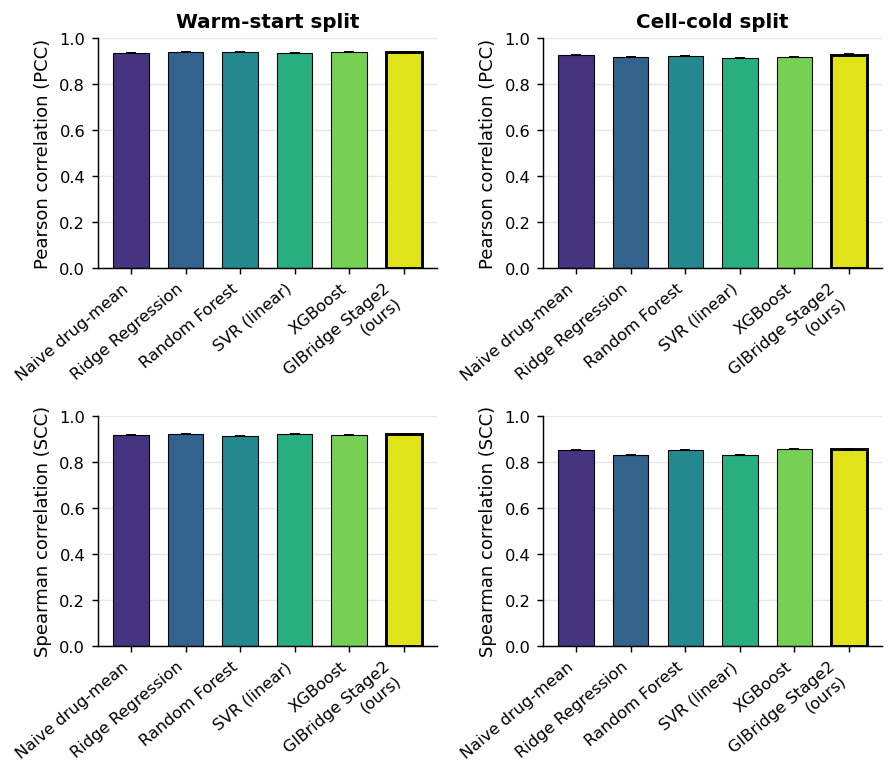

In [10]:
section('Comparison figure: PCC and SCC by method')

active_splits = []
if RUN_WARM:
    active_splits.append(('Warm-start split', warm_baseline_results, warm_summary))
if RUN_COLD:
    active_splits.append(('Cell-cold split', cellcold_baseline_results, cellcold_summary))

labels_bar = METHODS_ORDER + ['GIBridge Stage2\n(ours)']
bar_colors = viridis_colors(len(labels_bar))
edge_widths = [0.6] * (len(labels_bar) - 1) + [1.6]
metrics_to_plot = [('pcc', 'Pearson correlation (PCC)'), ('scc', 'Spearman correlation (SCC)')]

n_rows, n_cols = len(metrics_to_plot), len(active_splits)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(DOUBLE_COL[0] if n_cols == 2 else 4.2, DOUBLE_COL[1] * n_rows * 0.9),
                          squeeze=False)

for row_i, (metric_key, metric_label) in enumerate(metrics_to_plot):
    for col_i, (title, baseline_results, summary) in enumerate(active_splits):
        ax = axes[row_i][col_i]
        vals = [baseline_results[m][metric_key] for m in METHODS_ORDER] + [summary[f'{metric_key}_mean']]
        errs = [0] * len(METHODS_ORDER) + [summary[f'{metric_key}_std']]
        ax.bar(labels_bar, vals, yerr=errs, color=bar_colors, edgecolor='black',
               linewidth=edge_widths, capsize=3, width=0.65)
        ax.set_ylabel(metric_label); ax.set_ylim(0, 1.0)
        ax.set_title(title if row_i == 0 else '')
        ax.tick_params(axis='x', rotation=40)
        for lbl in ax.get_xticklabels():
            lbl.set_ha('right')

fig.tight_layout()
save_fig(fig, 'gibridge_stage2_comparison_barplot', CONFIG['OUT_DIR'])
plt.show()


  Predicted vs. measured ln(IC50)


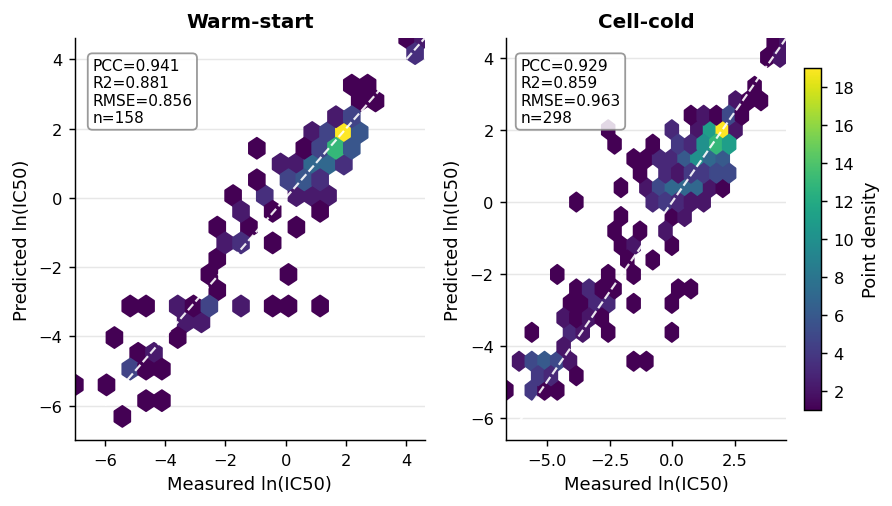

In [11]:
section('Predicted vs. measured ln(IC50)')

def plot_pred_vs_actual(ax, y_true, y_pred, title, metrics):
    hb = ax.hexbin(y_true, y_pred, gridsize=22, cmap='viridis', mincnt=1)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color='white', linestyle='--', linewidth=1.2, alpha=0.9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Measured ln(IC50)'); ax.set_ylabel('Predicted ln(IC50)')
    ax.set_title(title)
    txt = f'PCC={metrics["pcc"]:.3f}\nR2={metrics["r2"]:.3f}\nRMSE={metrics["rmse"]:.3f}\nn={len(y_true)}'
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top', ha='left', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor=BASELINE_GREY))
    return hb

active_refs = []
if RUN_WARM:
    active_refs.append(('Warm-start', warm_summary['runs'][0]))
if RUN_COLD:
    active_refs.append(('Cell-cold', cellcold_summary['runs'][0]))

fig, axes = plt.subplots(1, len(active_refs), figsize=(DOUBLE_COL[0] if len(active_refs) == 2 else 4.6, DOUBLE_COL[1] + 0.6))
if len(active_refs) == 1:
    axes = [axes]

last_hb = None
for ax, (title, ref) in zip(axes, active_refs):
    last_hb = plot_pred_vs_actual(ax, ref['labels'], ref['preds'], title, ref)
fig.colorbar(last_hb, ax=axes[-1], label='Point density', shrink=0.85)
fig.tight_layout()
save_fig(fig, 'gibridge_stage2_scatter', CONFIG['OUT_DIR'])
plt.show()

In [12]:
section('Save artifacts')

if RUN_WARM:
    for i, s in enumerate(CONFIG['seeds']):
        torch.save(warm_summary['runs'][i]['state_dict'], f'{CONFIG["OUT_DIR"]}gibridge_stage2_warm_seed{s}.pt')
    best_warm_i = int(np.argmax([r['pcc'] for r in warm_summary['runs']]))
    import shutil
    shutil.copy(f'{CONFIG["OUT_DIR"]}gibridge_stage2_warm_seed{CONFIG["seeds"][best_warm_i]}.pt',
                f'{CONFIG["OUT_DIR"]}gibridge_stage2_warm_best.pt')
    print(f'Saved {len(CONFIG["seeds"])} warm-split checkpoints + best-seed copy')

if RUN_COLD:
    for i, s in enumerate(CONFIG['seeds']):
        torch.save(cellcold_summary['runs'][i]['state_dict'], f'{CONFIG["OUT_DIR"]}gibridge_stage2_cellcold_seed{s}.pt')
    best_cc_i = int(np.argmax([r['pcc'] for r in cellcold_summary['runs']]))
    import shutil
    shutil.copy(f'{CONFIG["OUT_DIR"]}gibridge_stage2_cellcold_seed{CONFIG["seeds"][best_cc_i]}.pt',
                f'{CONFIG["OUT_DIR"]}gibridge_stage2_cellcold_best.pt')
    print(f'Saved {len(CONFIG["seeds"])} cell-cold checkpoints + best-seed copy')

with open(f'{CONFIG["OUT_DIR"]}gibridge_stage2_training_config.json', 'w') as f:
    json.dump({**CONFIG, 'DATA_BASE': DATA_BASE, 'CKPT_PATH': CKPT_PATH}, f, indent=2)
print('Saved training config JSON.')


  Save artifacts
Saved 3 warm-split checkpoints + best-seed copy
Saved 3 cell-cold checkpoints + best-seed copy
Saved training config JSON.



  Predicted drug-sensitivity deviation -- GI lineages x drugs (signed delta IC50)


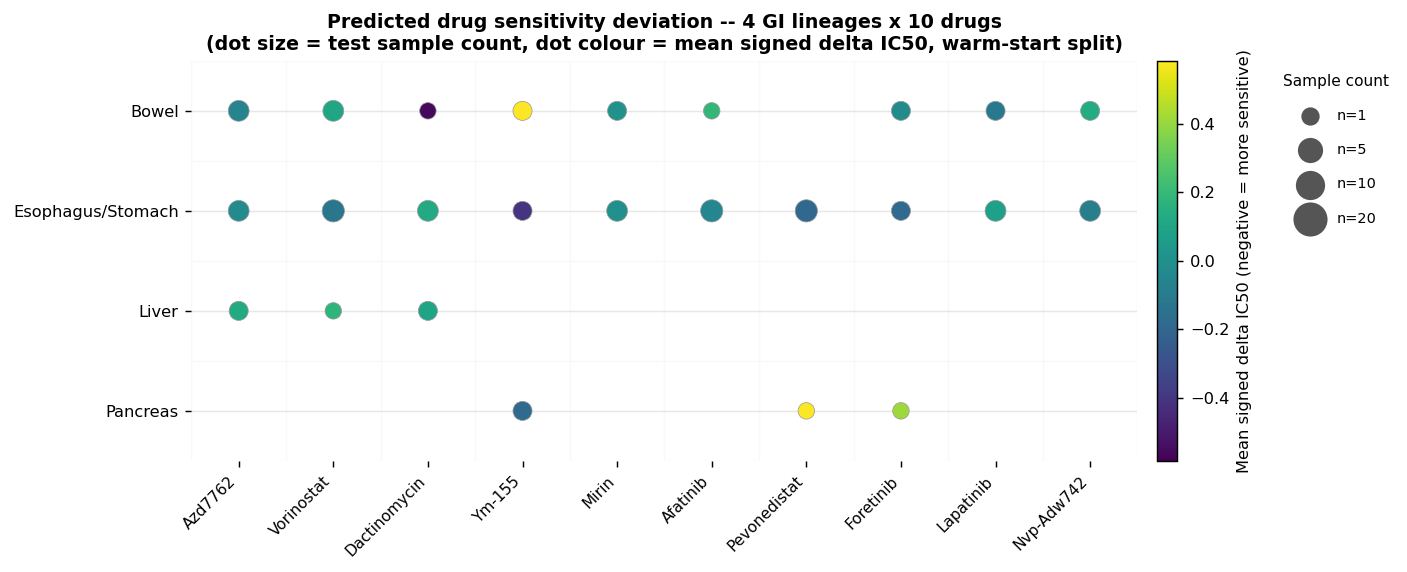

In [13]:
section('Predicted drug-sensitivity deviation -- GI lineages x drugs (signed delta IC50)')

TOP_N_DRUGS_DOTPLOT = 10   # or replace the line below with your own hand-picked list

ref = warm_summary['runs'][0]   # seed=42, warm split -- swap to cellcold_summary for that split
test_reset = warm_test.reset_index(drop=True)
assert len(test_reset) == len(ref['preds']), 'row-count mismatch -- reload warm_test before running this cell'

pred_df = pd.DataFrame({
    'pred_ic50': ref['preds'].astype(np.float64),
    'drug_name': test_reset['DRUG_NAME'].values,
    'lineage':   test_reset['OncotreeLineage'].values,
})

drug_mean_pred = pred_df.groupby('drug_name')['pred_ic50'].mean()
pred_df['delta_ic50'] = pred_df['pred_ic50'] - pred_df['drug_name'].map(drug_mean_pred)
""
top_drugs_dotplot = pred_df['drug_name'].value_counts().head(TOP_N_DRUGS_DOTPLOT).index.tolist()
# top_drugs_dotplot = ['DRUG_A', 'DRUG_B', ...]   # <- uncomment to hand-pick instead

ROW_LABELS = sorted(pred_df['lineage'].dropna().unique())
row_to_y = {r: i for i, r in enumerate(ROW_LABELS)}
drug_to_x = {d: i for i, d in enumerate(top_drugs_dotplot)}

sub = pred_df[pred_df['drug_name'].isin(top_drugs_dotplot) & pred_df['lineage'].isin(ROW_LABELS)]
agg = sub.groupby(['lineage', 'drug_name']).agg(
    mean_delta=('delta_ic50', 'mean'), n=('delta_ic50', 'size')
).reset_index()
agg['x'] = agg['drug_name'].map(drug_to_x)
agg['y'] = agg['lineage'].map(row_to_y)

SIZE_MIN, SIZE_MAX = 15, 320
n_capped = np.clip(agg['n'], 1, 20)
agg['dot_size'] = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * (np.sqrt(n_capped) / np.sqrt(20))

vlim = np.nanpercentile(agg['mean_delta'].abs(), 95)
if not np.isfinite(vlim) or vlim == 0:
    vlim = max(agg['mean_delta'].abs().max(), 1e-6)

fig, ax = plt.subplots(figsize=(11, 4.5))
sc = ax.scatter(agg['x'], agg['y'], s=agg['dot_size'], c=agg['mean_delta'],
                 cmap='viridis', vmin=-vlim, vmax=vlim, edgecolors='#999999', linewidths=0.4)

ax.set_xlim(-0.5, len(top_drugs_dotplot) - 0.5)
ax.set_ylim(len(ROW_LABELS) - 0.5, -0.5)
ax.set_xticks(range(len(top_drugs_dotplot)))
ax.set_xticklabels([str(d).title() for d in top_drugs_dotplot], rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(ROW_LABELS)))
ax.set_yticklabels(ROW_LABELS, fontsize=9)

ax.set_xticks(np.arange(-0.5, len(top_drugs_dotplot), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(ROW_LABELS), 1), minor=True)
ax.grid(which='minor', color='#eeeeee', linewidth=0.8)
ax.tick_params(which='minor', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Mean signed delta IC50 (negative = more sensitive)', fontsize=9)

for n_ref in [1, 5, 10, 20]:
    size_ref = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * (np.sqrt(min(n_ref, 20)) / np.sqrt(20))
    ax.scatter([], [], s=size_ref, color='#555555', label=f'n={n_ref}')
ax.legend(scatterpoints=1, frameon=False, labelspacing=1.4, title='Sample count',
          title_fontsize=8.5, fontsize=8, loc='upper left', bbox_to_anchor=(1.14, 1.0))

ax.set_title(f'Predicted drug sensitivity deviation -- {len(ROW_LABELS)} GI lineages x {len(top_drugs_dotplot)} drugs\n'
             f'(dot size = test sample count, dot colour = mean signed delta IC50, warm-start split)',
             fontsize=10.5, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'gibridge_stage2_delta_ic50_dotplot', CONFIG['OUT_DIR'])
plt.show()


  Modality sensitivity per drug -- gradient attribution (NOT attention; see note)
GIBridge Stage 2 has no cross-attention module -- it is drug_bias + residual_MLP on a
concatenated vector, no learned attention weights exist to extract. This is a genuine
substitute: mean absolute gradient of predicted IC50 w.r.t. each of the 4 modality segments
of the frozen patient embedding. Label it "gradient attribution" or "input sensitivity" in
the paper -- calling it "attention" would misdescribe the architecture.



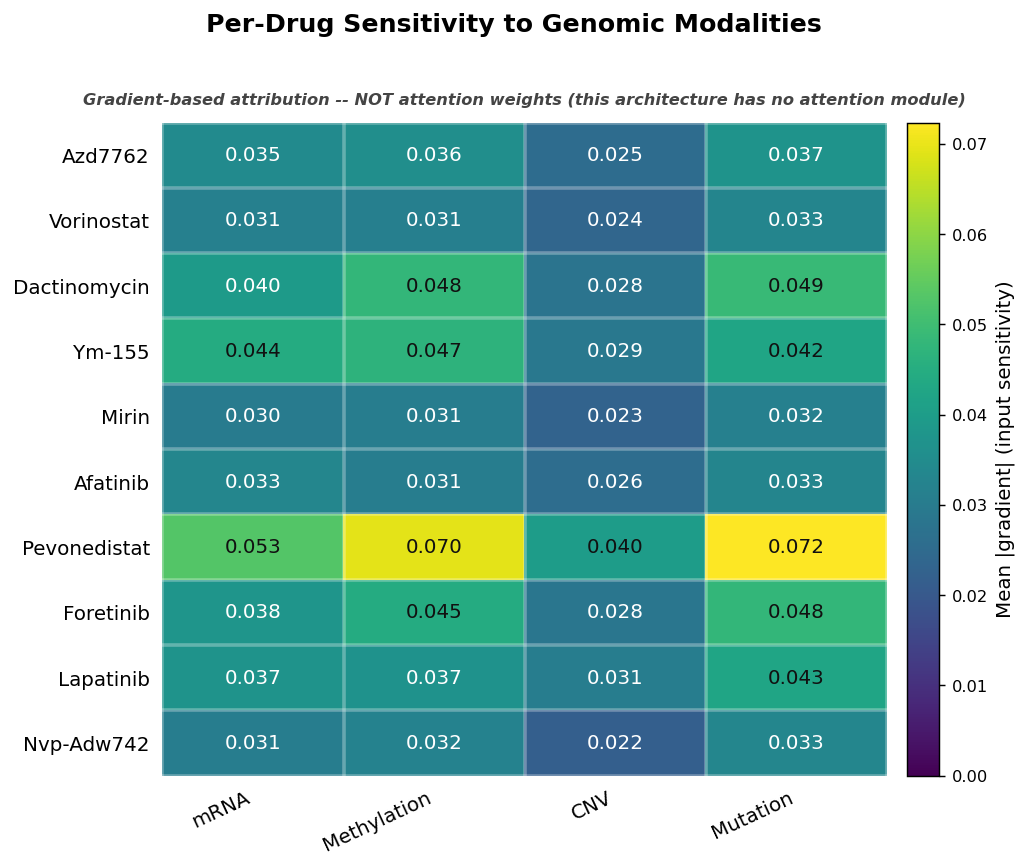

In [14]:
section('Modality sensitivity per drug -- gradient attribution (NOT attention; see note)')
print('GIBridge Stage 2 has no cross-attention module -- it is drug_bias + residual_MLP on a')
print('concatenated vector, no learned attention weights exist to extract. This is a genuine')
print('substitute: mean absolute gradient of predicted IC50 w.r.t. each of the 4 modality segments')
print('of the frozen patient embedding. Label it "gradient attribution" or "input sensitivity" in')
print('the paper -- calling it "attention" would misdescribe the architecture.\n')

TOP_N_DRUGS_SAL = 10
top_drugs_sal = warm_test['DRUG_NAME'].value_counts().head(TOP_N_DRUGS_SAL).index.tolist()
modality_labels = ['mRNA', 'Methylation', 'CNV', 'Mutation']   # matches FrozenPatientEncoder concat order
modality_slices = [(0, 32), (32, 64), (64, 96), (96, 128)]

idx_to_drug = {v: k for k, v in drug_to_idx.items()}

ref_model = warm_model_fn()
ref_model.load_state_dict(warm_summary['runs'][0]['state_dict'])
ref_model = ref_model.to(DEVICE)
ref_model.eval()

sal_sum = {d: np.zeros(4) for d in top_drugs_sal}
sal_count = {d: 0 for d in top_drugs_sal}

for pe_b, fp_b, idx_b, y_b in warm_test_loader:
    pe_b = pe_b.to(DEVICE).clone().requires_grad_(True)
    fp_b, idx_b = fp_b.to(DEVICE), idx_b.to(DEVICE)
    preds = ref_model(pe_b, fp_b, idx_b)
    preds.sum().backward()
    grad = pe_b.grad.abs().cpu().numpy()

    dnames = [idx_to_drug.get(int(x), None) for x in idx_b.cpu().numpy()]
    for i, dn in enumerate(dnames):
        if dn in sal_sum:
            seg_scores = np.array([grad[i, s:e].mean() for s, e in modality_slices])
            sal_sum[dn] += seg_scores
            sal_count[dn] += 1

rows, row_labels = [], []
for d in top_drugs_sal:
    if sal_count[d] > 0:
        rows.append(sal_sum[d] / sal_count[d])
        row_labels.append(str(d).title())
heat = np.array(rows)

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(heat, cmap='viridis', aspect='auto', vmin=0, vmax=heat.max())
vmax = heat.max()
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat[i, j]
        txt_color = 'white' if val < vmax * 0.55 else '#111111'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=11, color=txt_color)

ax.set_xticks(range(len(modality_labels)))
ax.set_xticklabels(modality_labels, fontsize=11, rotation=25, ha='right')
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=11)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(modality_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2.0)
ax.tick_params(which='minor', bottom=False, left=False)
ax.tick_params(which='major', bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.025)
cbar.set_label('Mean |gradient| (input sensitivity)', fontsize=11)

fig.suptitle('Per-Drug Sensitivity to Genomic Modalities', fontsize=14, fontweight='bold', y=1.02)
ax.set_title('Gradient-based attribution -- NOT attention weights (this architecture has no attention module)',
             fontsize=9, style='italic', color='#444444', pad=10)
plt.tight_layout()
save_fig(fig, 'gibridge_stage2_modality_sensitivity', CONFIG['OUT_DIR'])
plt.show()

In [15]:
section('Save drug vocabulary (for the Stage 1 target-prioritization cross-reference)')

with open(f'{CONFIG["OUT_DIR"]}gibridge_stage2_drug_vocab.json', 'w') as f:
    json.dump(drug_to_idx, f, indent=2)

print(f'Saved {len(drug_to_idx)} drugs to gibridge_stage2_drug_vocab.json')
print('Upload this file (or the whole /kaggle/working/ output) as a dataset, then point')
print('CONFIG_TP["DRUG_LIST_PATH"] at it from the Stage 1 target-prioritization pipeline.')


  Save drug vocabulary (for the Stage 1 target-prioritization cross-reference)
Saved 71 drugs to gibridge_stage2_drug_vocab.json
Upload this file (or the whole /kaggle/working/ output) as a dataset, then point
CONFIG_TP["DRUG_LIST_PATH"] at it from the Stage 1 target-prioritization pipeline.


## Summary

- Loads directly from `DATA_BASE` (the output of `GIBridge_Stage2_DataPrep_v3.ipynb`) --
  no raw CCLE/GDSC2 code in this notebook, matching your established two-notebook workflow.
- Frozen Stage 1 v3 patient encoder (gene counts inferred from the loaded parquet shapes,
  so this notebook never needs the Stage 1 gene-name JSONs directly -- only the checkpoint).
- `drug_bias + residual_MLP`, no lineage term, no backbone unfreezing.
- `RUN_WARM` / `RUN_COLD` control which split(s) load, train, and appear in the baselines,
  table, and figures.
- Metrics restricted to PCC / SCC / RMSE / R\u00b2, matching the OncoBridge Stage 2 convention.

## What to check first

1. **Cell 2's gene counts** should exactly match Stage 1 v3's `CONFIG['gene_counts']`
   (500/300/300/500) -- if not, `DATA_BASE` is pointing at data processed against the wrong
   Stage 1 gene selection.
2. **Cell 7's warm-to-cold PCC drop, against the naive baseline's own drop (Cell 8).**
3. **Table A** -- does the neural model beat Ridge/RF/SVR/XGBoost on the same features?